In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier as KNC

### Méthode avec random.normal (2D)

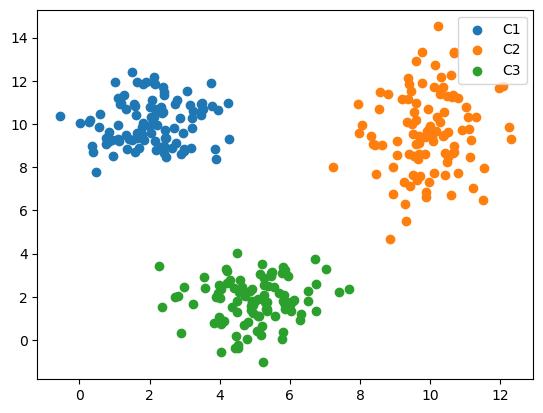

In [6]:
np.random.seed(0)

X1 = np.random.normal(2, 1, 100)
Y1 = np.random.normal(10, 1, 100)

X2 = np.random.normal(10, 1, 100)
Y2 = np.random.normal(10, 2, 100)

X3 = np.random.normal(5, 1, 100)
Y3 = np.random.normal(2, 1, 100)


plt.scatter(X1, Y1, label="C1")
plt.scatter(X2, Y2, label="C2")
plt.scatter(X3, Y3, label="C3")
plt.legend()

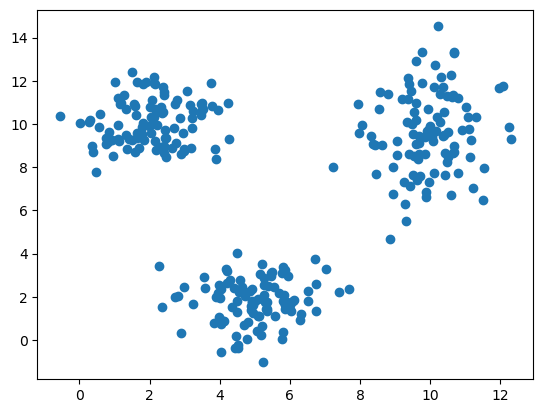

In [362]:
X_all = np.hstack([X1, X2, X3])
Y_all = np.hstack([Y1, Y2, Y3])

df = pd.DataFrame({"X" : X_all, "Y": Y_all})
X = df[["X"]]
Y = df[["Y"]]
plt.scatter(X, Y)

## Création des données
### Methode avec random.multivariate_normal (3D ou plus)

In [30]:
mean1 = [2, 2, 4]
mean2 = [0, 0, 0]
mean3 = [6, 6, 7]

cov1 = np.eye(3)*0.01
cov2 = np.eye(3)*0.01
cov3 = np.eye(3)*0.01

cov = np.diag([1, 1, 0.2])

In [32]:
np.random.seed(0)
df_multi = np.vstack([
    np.random.multivariate_normal(mean1, cov, 4000),
    np.random.multivariate_normal(mean2, cov, 1000),
    np.random.multivariate_normal(mean3, cov, 6000)
])

df_multi = pd.DataFrame({"X":df_multi[:, 0], "Y":df_multi[:, 1], "Z":df_multi[:, 2]})
df_multi.head()

,X,Y,Z
0,2.400157,3.764052,4.437705
1,3.867558,4.240893,3.562948
2,1.848643,2.950088,3.953839
3,2.144044,2.410599,4.650371
4,2.121675,2.761038,4.198502


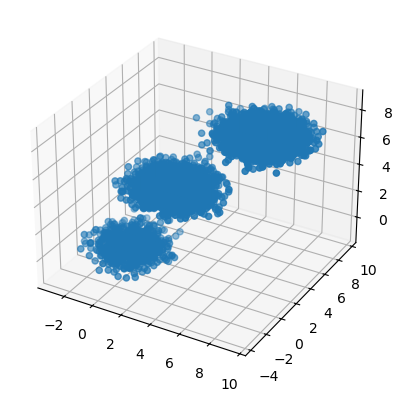

In [34]:
ax = plt.axes(projection='3d')
ax.scatter(df_multi.iloc[:, 0], df_multi.iloc[:, 1], df_multi.iloc[:, 2])
plt.show()

## Apprentissage non supervisé / DBSCAN

### Recherche de paramètres

In [12]:
def eval_dbscan(df, eps_val, spl_val, echantillonage_size):
    dbs = DBSCAN(eps= eps_val, min_samples=spl_val, metric="euclidean")
    dbs.fit(df)
    labels = dbs.labels_ # On obtient l'array des classes de chaque échantillon de données
    df_unnoise = df.copy()
    df_unnoise["labels"] = labels # On ajoute la colonne des labels à df_unnoise
    df_unnoise = df_unnoise[df_unnoise["labels"] != -1] #... puis on filtre tous les noise points

    # On prend au hasard la moitié du dataset pour calculer le silhouette score plus rapidement
    df_random = df_unnoise.sample(frac=echantillonage_size, replace=True, random_state=42)

    score_metric = 0
    if (len(np.unique(df_random[["labels"]])) >= 2): #il faut au moins 2 clusters pour pouvoir calculer le silhouette_score
        score_metric = silhouette_score(df_random.drop("labels", axis=1) , df_random["labels"].to_numpy())
    else:
        score_metric = -1

    return {
        "Score_metric":score_metric, 
        "Epsilon":eps_val, 
        "Min_Samples":spl_val, 
        "Nb_Clusters":len(np.unique(labels[labels != -1]))
    }


def unsupervised_metric(df, epsilons_tab, samples_tab, echantillonage_size):
    #On créer tous les couples de eps et min_samples possibles
    couples = [(i, j) for i in epsilons_tab for j in samples_tab]

    # On parallélise avec Parrallel et delay la fonction eval_dbscan()
    results = Parallel(n_jobs=10)(
        delayed(eval_dbscan)(df, eps, spl, echantillonage_size)
        for eps, spl in couples
    )

    # On met tous ces résulats dans un dataframe
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by=["Score_metric"], ascending=False)
    
    return results_df

In [14]:
epsilons_tab = np.arange(0.1, 2, 0.1)
samples_tab = np.arange(2, 10, 1)

In [36]:
scores = unsupervised_metric(df_multi, epsilons_tab, samples_tab, echantillonage_size = 0.5)

In [37]:
scores

,Score_metric,Epsilon,Min_Samples,Nb_Clusters
31,0.690146,0.4,9,3
27,0.685391,0.4,5,3
45,0.679062,0.6,7,3
38,0.678647,0.5,8,3
39,0.678206,0.5,9,3
...,...,...,...,...
122,-1.000000,1.6,4,1
123,-1.000000,1.6,5,1
124,-1.000000,1.6,6,1
125,-1.000000,1.6,7,1


### Apprentissage final avec les meilleurs hyperparamètres de DBSCAN

In [16]:
dbs_f = DBSCAN(eps = 0.4, min_samples=9)
dbs_f.fit(df_multi)

DBSCAN(eps=0.4, min_samples=9)

In [18]:
labels = dbs_f.labels_ # On extrait les classes
df_multi["labels"] = labels # On l'ajoute à notre dataset
df_multi = df_multi[df_multi['labels']!=-1] # Suppression des bruits / Noise points
np.unique(df_multi["labels"])

array([0, 1, 2], dtype=int64)

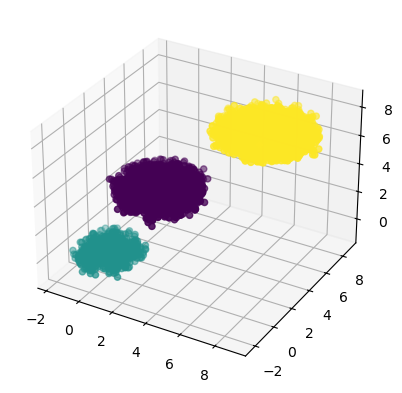

In [20]:
ax = plt.axes(projection="3d")
ax.scatter(df_multi.iloc[:, 0], df_multi.iloc[:, 1], df_multi.iloc[:, 2], c=df_multi["labels"])
plt.show()

### Entraînement du modèle KNN

### Train_test_split

In [24]:
X = df_multi[["X", "Y", "Z"]]
Y = df_multi["labels"].to_numpy()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42, shuffle=True)

In [26]:
X_train.head()

,X,Y,Z
2241,1.118985,1.905634,4.677048
417,3.045023,2.271113,4.267899
3273,0.431971,1.108572,3.716998
1835,2.257596,1.374735,3.339689
599,1.529258,2.183450,4.121998


### Pipeline & Grid Search CV

In [29]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNC())
])

In [31]:
param_grid_knn = {
    'knn__metric' : ['euclidean', 'manhattan'],
    'knn__n_neighbors' : [2, 3, 4, 5, 6, 7]
}

In [33]:
grid = GridSearchCV(
    estimator = pipe_knn, 
    param_grid = param_grid_knn, 
    scoring = 'accuracy', 
    cv = StratifiedKFold(n_splits=5), 
    n_jobs=9
)

In [35]:
grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=9,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [2, 3, 4, 5, 6, 7]},
             scoring='accuracy')

In [36]:
knc_final = grid.best_estimator_
predictions = knc_final.predict(X_test)

In [37]:
knc_final.score(X_test, Y_test)

1.0

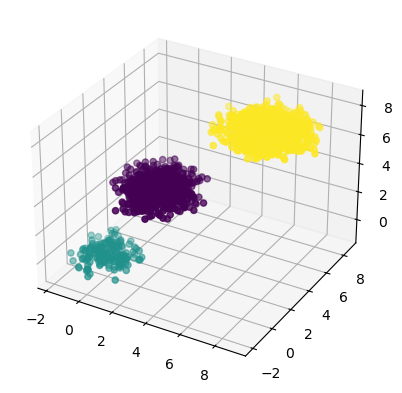

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], X_test.iloc[:, 2], c=predictions)

## K-Means

### On crée une copie du dataframe pour repartir de zéro et on les standardise

In [40]:
df_multi2 = df_multi.copy().drop('labels', axis=1)
df_multi2.head(2)

,X,Y,Z
0,2.400157,3.764052,4.437705
2,1.848643,2.950088,3.953839


In [41]:
df_multi2 = StandardScaler().fit_transform(df_multi2)
df_multi2 = pd.DataFrame(df_multi2, columns=df_multi.columns[:-1])
df_multi2.head()

,X,Y,Z
0,-0.704856,-0.127810,-0.441235
1,-0.933597,-0.464194,-0.668334
2,-0.811079,-0.687147,-0.341422
3,-0.820357,-0.542322,-0.553503
4,-0.251152,-0.718937,-0.689730


### Recherche d'hyperparamètres manuellement

In [49]:
def eval_kmeans(df, n_clusters_val, n_max_iter_val, n_init_val, echantillonage_size):
    model_kmeans = KMeans(n_clusters = n_clusters_val, max_iter = n_max_iter_val, n_init = n_init_val)
    model_kmeans.fit(df)
    labels = model_kmeans.labels_ # On obtient l'array des classes de chaque échantillon de données
    df_unnoise = df.copy()
    df_unnoise["labels"] = labels # On ajoute la colonne des labels à df_unnoise
    df_unnoise = df_unnoise[df_unnoise["labels"] != -1] #... puis on filtre tous les noise points

    # On prend au hasard la moitié du dataset pour calculer le silhouette score plus rapidement
    df_random = df_unnoise.sample(frac=echantillonage_size, replace=True, random_state=42)

    score_silhouette = 0
    score_calinski = 0
    score_davies_bouldin = 0
    if (len(np.unique(df_random[["labels"]])) >= 2): #il faut au moins 2 clusters pour pouvoir calculer le silhouette_score
        score_silhouette = silhouette_score(df_random.drop("labels", axis=1) , df_random["labels"].to_numpy())
        score_calinski = calinski_harabasz_score(df_random.drop("labels", axis=1) , df_random["labels"].to_numpy())
        score_davies_bouldin = davies_bouldin_score(df_random.drop("labels", axis=1) , df_random["labels"].to_numpy())
        
    else: # Si il y a moins de 2 clusters, alors on met les scores à leur plus bas
        score_silhouette = -1
        score_calinski = 0
        score_davies_bouldin = np.inf

    return {
        "Silhouette_score":score_silhouette,
        "Calinski_Harabasz_score":score_calinski,
        "Davies_Bouldin_score":score_davies_bouldin,
        "n_clusters_val":n_clusters_val, 
        "n_max_iter_val":n_max_iter_val, 
        "n_init_val":n_init_val, 
        "Nb_Clusters":len(np.unique(labels[labels != -1]))
    }


def unsupervised_metric(df, n_clusters_tab, n_max_iter_tab, n_init_tab, echantillonage_size):
    #On créer tous les couples de eps et min_samples possibles
    couples = [(i, j, k) for i in n_clusters_tab for j in n_max_iter_tab for k in n_init_tab]

    # On parallélise avec Parrallel et delay la fonction eval_dbscan()
    results = Parallel(n_jobs=10)(
        delayed(eval_kmeans)(df, i, j, k, echantillonage_size)
        for i, j, k in couples
    )

    # On met tous ces résulats dans un dataframe
    results_df = pd.DataFrame(results)
    #results_df = results_df.sort_values(by=["Score_metric"], ascending=False)
    # On ne peut pas trier par ordre décroisssant car on a 3 métriques d'évaluation différentes
    
    return results_df

In [58]:
n_clusters_tab = [2, 3, 4]
n_max_iter_tab = [100, 300, 500, 1000]
n_init_tab = [2, 3, 4, 5]

In [60]:
best_kmeans_hpp = unsupervised_metric(df_multi2, n_clusters_tab, n_max_iter_tab, n_init_tab, 0.5)

In [61]:
best_kmeans_hpp

,Silhouette_score,Calinski_Harabasz_score,Davies_Bouldin_score,n_clusters_val,n_max_iter_val,n_init_val,Nb_Clusters
0,0.698334,19143.038192,0.453475,2,100,2,2
1,0.698334,19143.038192,0.453475,2,100,3,2
2,0.698334,19143.038192,0.453475,2,100,4,2
3,0.698334,19143.038192,0.453475,2,100,5,2
4,0.698334,19143.038192,0.453475,2,300,2,2
5,0.698334,19143.038192,0.453475,2,300,3,2
6,0.698334,19143.038192,0.453475,2,300,4,2
7,0.698334,19143.038192,0.453475,2,300,5,2
8,0.698334,19143.038192,0.453475,2,500,2,2
9,0.698334,19143.038192,0.453475,2,500,3,2


### Recherche des meilleurs Hyperparamètres.
#### On cherche les Hyperparamètres qui maximisent les Silhouette et Calinski scores mais qui minimise le Davies Bouldin Score

In [189]:
def fonction_cout_hpp(df_scores_kmeans): # df score est au format csv
    mms = MinMaxScaler()
    tab_score = df_scores_kmeans.copy()
    tab_score = tab_score.iloc[:, :3]
    tab_score = mms.fit_transform(tab_score) # Il devient un ndarray
    tab_score = tab_score[:, 0] + tab_score[:, 1] - tab_score[:, 2]
    best_global_score_idx = np.argmax(tab_score)

    best_n_clusters_val = df_scores_kmeans.iloc[best_global_score_idx, 3]
    best_n_max_iter_val = df_scores_kmeans.iloc[best_global_score_idx, 4]
    best_n_init_val = df_scores_kmeans.iloc[best_global_score_idx, 5]
    
    return best_n_clusters_val, best_n_max_iter_val, best_n_init_val

In [64]:
best_n_clusters_val, best_n_max_iter_val, best_n_init_val = fonction_cout_hpp(best_kmeans_hpp)

In [65]:
best_n_clusters_val, best_n_max_iter_val, best_n_init_val

(3, 100, 2)

### Apprentissage final avec les meilleurs hyperparamètres du Kmeans

In [72]:
kmeans_f = KMeans(n_clusters = 3, max_iter=100, n_init=2)

In [74]:
kmeans_f.fit(df_multi2)

KMeans(max_iter=100, n_clusters=3, n_init=2)

In [76]:
df_multi2["labels"] = kmeans_f.labels_
df_multi2.head()

,X,Y,Z,labels
0,-0.704856,-0.127810,-0.441235,1
1,-0.933597,-0.464194,-0.668334,1
2,-0.811079,-0.687147,-0.341422,1
3,-0.820357,-0.542322,-0.553503,1
4,-0.251152,-0.718937,-0.689730,1


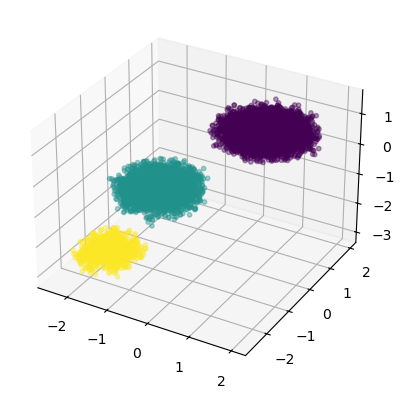

In [78]:
fig = plt.figure()
ax = plt.subplot(111, projection='3d')
ax.scatter(df_multi2.iloc[:, 0], df_multi2.iloc[:, 1], df_multi2.iloc[:, 2], c=df_multi2.iloc[:, 3], s=10, alpha=0.4)

# PS : Mes données d'entraînement df_multi2 ont été Standardisée juste avant

### Entraînement avec KNN & Train_test_split

In [81]:
X_train, X_test, Y_train, Y_test = train_test_split(df_multi2.drop("labels", axis=1), df_multi2["labels"].to_numpy(), test_size=0.20, random_state=42, shuffle=True)

In [83]:
param_grid_knn2 = {
    "metric" : ["euclidean", "manhattan"],
    "n_neighbors" : np.arange(2, 10, 1)
}

In [85]:
grid2 = GridSearchCV(
    estimator = KNC(),
    param_grid = param_grid_knn2,
    scoring = "accuracy",
    cv = StratifiedKFold(n_splits=5),
    n_jobs = 6
)

In [87]:
grid2.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=KNeighborsClassifier(), n_jobs=6,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='accuracy')

In [88]:
knc_final2 = grid2.best_estimator_

In [89]:
predictions2 = knc_final2.predict(X_test)
knc_final2.score(X_test, Y_test)

1.0

## Gaussian Mixture

In [36]:
from sklearn.mixture import GaussianMixture

In [42]:
df_multi3 = df_multi
df_multi3.head()

,X,Y,Z
0,2.400157,3.764052,4.437705
1,3.867558,4.240893,3.562948
2,1.848643,2.950088,3.953839
3,2.144044,2.410599,4.650371
4,2.121675,2.761038,4.198502


In [201]:
def eval_gaussian_mixture(df, n_components_val, tol_val, n_init_val, init_params_val_char, echantillonage_size):
    model_gm = GaussianMixture(n_components=n_components_val, tol=tol_val, n_init=n_init_val, init_params=init_params_val_char)
    model_gm.fit(df)
    labels = model_gm.predict(df) # On obtient l'array des classes de chaque échantillon de données
    df_unnoise = df.copy()
    df_unnoise["labels"] = labels # On ajoute la colonne des labels à df_unnoise
    #df_unnoise = df_unnoise[df_unnoise["labels"] != -1] # On n'a pas besoin de filtrer nos données car il n'y a pas d'outliers

    # On prend au hasard la moitié du dataset pour calculer le silhouette score plus rapidement
    df_random = df_unnoise.sample(frac=echantillonage_size, replace=False, random_state=42)

    score_silhouette = 0
    score_calinski = 0
    score_davies_bouldin = 0
    if (len(np.unique(df_random[["labels"]])) >= 2): #il faut au moins 2 clusters pour pouvoir calculer le silhouette_score
        score_silhouette = silhouette_score(df_random.drop("labels", axis=1) , df_random["labels"].to_numpy())
        score_calinski = calinski_harabasz_score(df_random.drop("labels", axis=1) , df_random["labels"].to_numpy())
        score_davies_bouldin = davies_bouldin_score(df_random.drop("labels", axis=1) , df_random["labels"].to_numpy())
        
    else: # Si il y a moins de 2 clusters, alors on met les scores à leur plus bas
        score_silhouette = -1
        score_calinski = 0
        score_davies_bouldin = np.inf

    return {
        "Silhouette_score":score_silhouette,
        "Calinski_Harabasz_score":score_calinski,
        "Davies_Bouldin_score":score_davies_bouldin,
        "n_components_val":n_components_val, 
        "tol_val":tol_val, 
        "n_init_val":n_init_val, 
        "init_params_val_char":init_params_val_char,
        "Nb_Clusters":len(np.unique(labels[labels != -1]))
    }


def unsupervised_metric(df, n_components_tab, tol_tab, n_init_tab, init_params_tab_char, echantillonage_size):
    #On créer tous les couples de eps et min_samples possibles
    couples = [(i, j, k, l) for i in n_components_tab for j in tol_tab for k in n_init_tab for l in init_params_tab_char]

    # On parallélise avec Parrallel et delay la fonction eval_dbscan()
    results = Parallel(n_jobs=7)(
        delayed(eval_gaussian_mixture)(df, i, j, k, l, echantillonage_size)
        for i, j, k, l in couples
    )

    # On met tous ces résulats dans un dataframe
    results_df = pd.DataFrame(results)
    
    return results_df

In [203]:
n_components_tab = [2, 3, 4]
tol_tab = np.arange(0.001, 0.005, 0.001)
n_init_tab = [2, 3]
init_params_tab_char = ['kmeans', 'k-means++', 'random', 'random_from_data']

In [205]:
best_gm_hpp = unsupervised_metric(df_multi3, n_components_tab, tol_tab, n_init_tab, init_params_tab_char, 0.5)

In [207]:
best_gm_hpp

,Silhouette_score,Calinski_Harabasz_score,Davies_Bouldin_score,n_components_val,tol_val,n_init_val,init_params_val_char,Nb_Clusters
0,0.677491,18366.045771,0.478559,2,0.001,2,kmeans,2
1,0.677491,18366.045771,0.478559,2,0.001,2,k-means++,2
2,0.345167,3361.964446,0.876346,2,0.001,2,random,2
3,0.677491,18366.045771,0.478559,2,0.001,2,random_from_data,2
4,0.677491,18366.045771,0.478559,2,0.001,3,kmeans,2
...,...,...,...,...,...,...,...,...
91,0.532925,14344.437883,0.940379,4,0.004,2,random_from_data,4
92,0.429455,15489.507084,0.977055,4,0.004,3,kmeans,4
93,0.532067,14130.365261,0.921934,4,0.004,3,k-means++,4
94,0.049535,934.939368,4.995411,4,0.004,3,random,4


In [242]:
def fonction_cout_hpp_gm(df_scores_gm): # df score est au format csv
    mms = MinMaxScaler()
    tab_score = df_scores_gm.copy()
    tab_score = tab_score.iloc[:, :3]
    tab_score = mms.fit_transform(tab_score) # Il devient un ndarray
    tab_score = tab_score[:, 0] + tab_score[:, 1] - tab_score[:, 2]
    best_global_score = np.max(tab_score)
    best_global_score_idx = np.argmax(tab_score)

    best_n_components_val = df_scores_gm.iloc[best_global_score_idx, 3]
    best_tol_val = df_scores_gm.iloc[best_global_score_idx, 4]
    best_n_init_val = df_scores_gm.iloc[best_global_score_idx, 5]
    best_init_params_char = df_scores_gm.iloc[best_global_score_idx, 6]
    
    return best_n_components_val, best_tol_val, best_n_init_val, best_init_params_char, best_global_score

In [244]:
best_n_components_val, best_tol_val, best_n_init_val, best_init_params_char, best_global_score = fonction_cout_hpp_gm(best_gm_hpp)

In [246]:
best_n_components_val, best_tol_val, best_n_init_val, best_init_params_char, best_global_score

(3, 0.001, 2, 'kmeans', 1.9860600677608444)

In [219]:
gm_f = GaussianMixture(n_components=3, tol=0.001, n_init=2, init_params='kmeans')

In [224]:
gm_f.fit(df_multi3)

GaussianMixture(n_components=3, n_init=2)

In [228]:
labels = gm_f.predict(df_multi3)
labels

array([2, 2, 2, ..., 1, 1, 1], dtype=int64)

In [232]:
df_multi3["labels"] = labels
df_multi3

,X,Y,Z,labels
0,2.400157,3.764052,4.437705,2
1,3.867558,4.240893,3.562948,2
2,1.848643,2.950088,3.953839,2
3,2.144044,2.410599,4.650371,2
4,2.121675,2.761038,4.198502,2
...,...,...,...,...
10995,6.218833,5.884258,6.585352,1
10996,5.251249,7.204948,5.884282,1
10997,6.194804,8.324878,6.579798,1
10998,7.126184,5.930441,6.356451,1


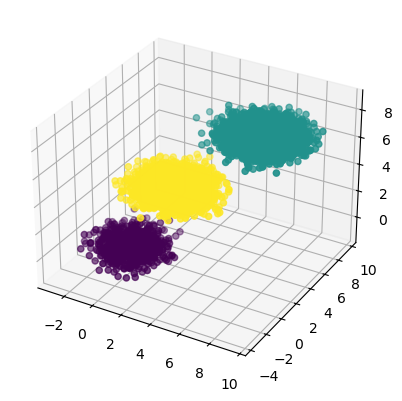

In [240]:
fig = plt.figure()
ax = plt.subplot(111, projection='3d')
ax.scatter(df_multi3.iloc[:, 0], df_multi3.iloc[:, 1], df_multi3.iloc[:, 2], c=df_multi3.iloc[:, 3])